In [1]:
import os, sys
# Ensure working directory is the repo root so asvFormula package and relative paths work correctly
if os.path.basename(os.getcwd()) == 'experiments':
    os.chdir('..')
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Topological Sort Comparison: `randomTopoSorts` vs `mcmcTopoSorts`

This notebook benchmarks two methods for sampling topological sorts:
- **`randomTopoSorts`**: exact weighted sampling using counts of linear extensions (works on poly-trees)
- **`mcmcTopoSorts`**: MCMC-based approximate sampling following Huber (1998) (works on arbitrary DAGs)

We compare runtime across:
1. Different **graph types** with increasing **number of nodes**
2. Different **number of samples** on a fixed graph

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from asvFormula.topoSorts.randomTopoSortsGeneration import randomTopoSorts, mcmcTopoSorts
from asvFormula.digraph import naiveBayes, balancedTree

sns.set_theme(style='whitegrid')

## Graph Factories

We test on three graph families:
- **Chain**: a simple directed path 0→1→2→…→n-1
- **Balanced binary tree**: root fans out hierarchically
- **Naive Bayes**: one root connected to all other nodes

In [5]:
def make_chain(n: int) -> nx.DiGraph:
    """Directed path graph 0->1->...->n-1."""
    g = nx.DiGraph()
    g.add_nodes_from(range(n))
    g.add_edges_from((i, i + 1) for i in range(n - 1))
    return g

def make_balanced_tree(n: int, branching_factor: int = 3) -> nx.DiGraph:
    """Balanced tree with configurable branching factor and at least n nodes."""
    if branching_factor < 1:
        raise ValueError("branching_factor must be >= 1")

    if n <= 0:
        return nx.DiGraph()

    # Special case: branching factor 1 is a chain
    if branching_factor == 1:
        return make_chain(n)

    # Smallest height whose full b-ary tree has at least n nodes:
    # (b^h - 1) / (b - 1) >= n  ->  h >= log_b(n*(b-1) + 1)
    height = max(2, int(np.ceil(np.log(n * (branching_factor - 1) + 1) / np.log(branching_factor))) + 1)
    g = balancedTree(height, branchingFactor=branching_factor)

    # Trim to exactly n nodes (keep first n in topological order)
    nodes_to_keep = list(nx.topological_sort(g))[:n]
    return g.subgraph(nodes_to_keep).copy()

def make_naive_bayes(n: int) -> nx.DiGraph:
    """Naive Bayes graph: root -> all other nodes."""
    return naiveBayes(n)

graph_factories = {
    'Chain': make_chain,
    'Balanced Tree': make_balanced_tree,
    'Naive Bayes': make_naive_bayes,
}

## Experiment 1: Scaling with Number of Nodes

Fix number of samples at 200, vary graph size.

In [7]:
NUM_SAMPLES = 200
NODE_COUNTS = [10, 12, 14, 16, 18]

records = []

for graph_name, factory in graph_factories.items():
    for n in NODE_COUNTS:
        g = factory(n)
        actual_n = g.number_of_nodes()

        # Time randomTopoSorts
        t0 = time.perf_counter()
        randomTopoSorts(g, NUM_SAMPLES)
        t_random = time.perf_counter() - t0

        # Time mcmcTopoSorts
        t0 = time.perf_counter()
        mcmcTopoSorts(g, NUM_SAMPLES)
        t_mcmc = time.perf_counter() - t0

        records.append({
            'Graph': graph_name,
            'Nodes': actual_n,
            'randomTopoSorts (s)': t_random,
            'mcmcTopoSorts (s)': t_mcmc,
        })
        print(f"{graph_name:15s} n={actual_n:3d}  random={t_random:.3f}s  mcmc={t_mcmc:.3f}s")

df_nodes = pd.DataFrame(records)

Chain           n= 10  random=0.003s  mcmc=0.222s
Chain           n= 12  random=0.002s  mcmc=0.382s
Chain           n= 14  random=0.002s  mcmc=0.509s
Chain           n= 16  random=0.003s  mcmc=0.740s
Chain           n= 18  random=0.003s  mcmc=1.072s
Balanced Tree   n= 10  random=0.022s  mcmc=0.210s
Balanced Tree   n= 12  random=0.051s  mcmc=0.357s
Balanced Tree   n= 14  random=0.085s  mcmc=0.504s
Balanced Tree   n= 16  random=0.173s  mcmc=0.746s
Balanced Tree   n= 18  random=0.371s  mcmc=1.216s
Naive Bayes     n= 10  random=0.033s  mcmc=0.213s
Naive Bayes     n= 12  random=0.095s  mcmc=0.451s
Naive Bayes     n= 14  random=0.322s  mcmc=0.567s
Naive Bayes     n= 16  random=0.569s  mcmc=0.806s
Naive Bayes     n= 18  random=0.911s  mcmc=1.167s


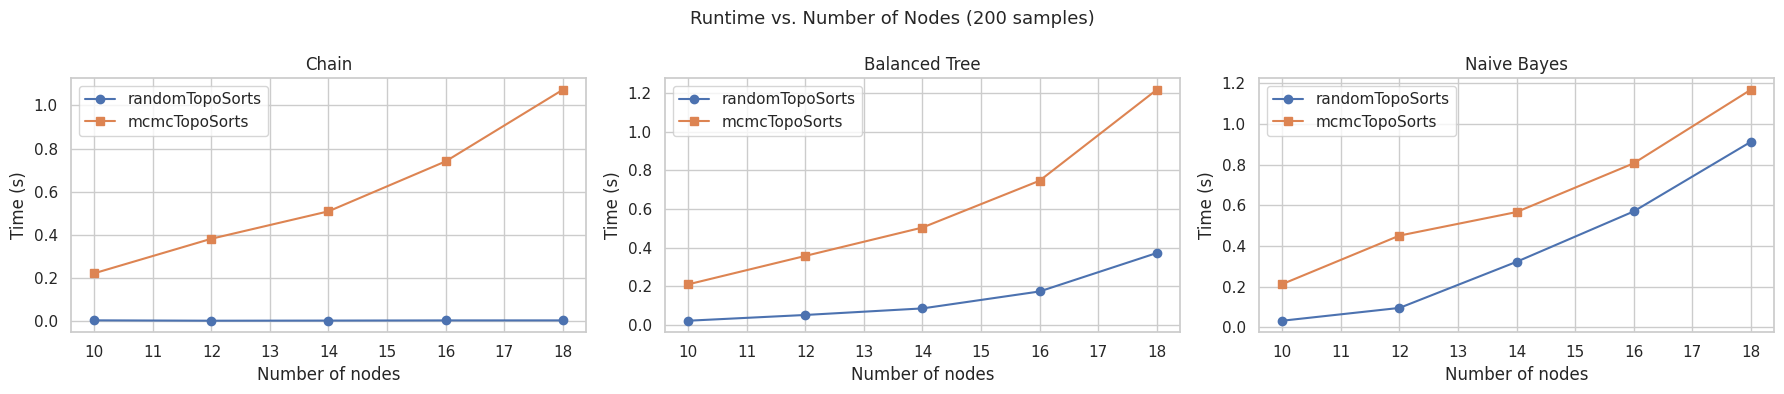

In [8]:
fig, axes = plt.subplots(1, len(graph_factories), figsize=(6 * len(graph_factories), 4), sharey=False)

for ax, (graph_name, _) in zip(axes, graph_factories.items()):
    sub = df_nodes[df_nodes['Graph'] == graph_name]
    ax.plot(sub['Nodes'], sub['randomTopoSorts (s)'], marker='o', label='randomTopoSorts')
    ax.plot(sub['Nodes'], sub['mcmcTopoSorts (s)'], marker='s', label='mcmcTopoSorts')
    ax.set_title(graph_name)
    ax.set_xlabel('Number of nodes')
    ax.set_ylabel('Time (s)')
    ax.legend()

fig.suptitle(f'Runtime vs. Number of Nodes ({NUM_SAMPLES} samples)', fontsize=13)
plt.tight_layout()
plt.show()

## Experiment 2: Scaling with Number of Samples

Fix a moderate-size graph (n=8) for each type, vary the number of requested samples.

In [10]:
FIXED_N = 12
SAMPLE_COUNTS = [10, 50, 100, 250, 500, 1000]

records_samples = []

for graph_name, factory in graph_factories.items():
    g = factory(FIXED_N)
    actual_n = g.number_of_nodes()

    for k in SAMPLE_COUNTS:
        t0 = time.perf_counter()
        randomTopoSorts(g, k)
        t_random = time.perf_counter() - t0

        t0 = time.perf_counter()
        mcmcTopoSorts(g, k)
        t_mcmc = time.perf_counter() - t0

        records_samples.append({
            'Graph': graph_name,
            'Samples': k,
            'randomTopoSorts (s)': t_random,
            'mcmcTopoSorts (s)': t_mcmc,
        })
        print(f"{graph_name:15s} k={k:5d}  random={t_random:.3f}s  mcmc={t_mcmc:.3f}s")

df_samples = pd.DataFrame(records_samples)

Chain           k=   10  random=0.001s  mcmc=0.044s
Chain           k=   50  random=0.001s  mcmc=0.176s
Chain           k=  100  random=0.001s  mcmc=0.178s
Chain           k=  250  random=0.002s  mcmc=0.400s
Chain           k=  500  random=0.003s  mcmc=0.948s
Chain           k= 1000  random=0.005s  mcmc=1.616s
Balanced Tree   k=   10  random=0.011s  mcmc=0.018s
Balanced Tree   k=   50  random=0.023s  mcmc=0.083s
Balanced Tree   k=  100  random=0.030s  mcmc=0.171s
Balanced Tree   k=  250  random=0.047s  mcmc=0.429s
Balanced Tree   k=  500  random=0.079s  mcmc=0.802s
Balanced Tree   k= 1000  random=0.119s  mcmc=1.608s
Naive Bayes     k=   10  random=0.014s  mcmc=0.020s
Naive Bayes     k=   50  random=0.044s  mcmc=0.083s
Naive Bayes     k=  100  random=0.067s  mcmc=0.167s
Naive Bayes     k=  250  random=0.096s  mcmc=0.400s
Naive Bayes     k=  500  random=0.140s  mcmc=0.816s
Naive Bayes     k= 1000  random=0.206s  mcmc=1.664s


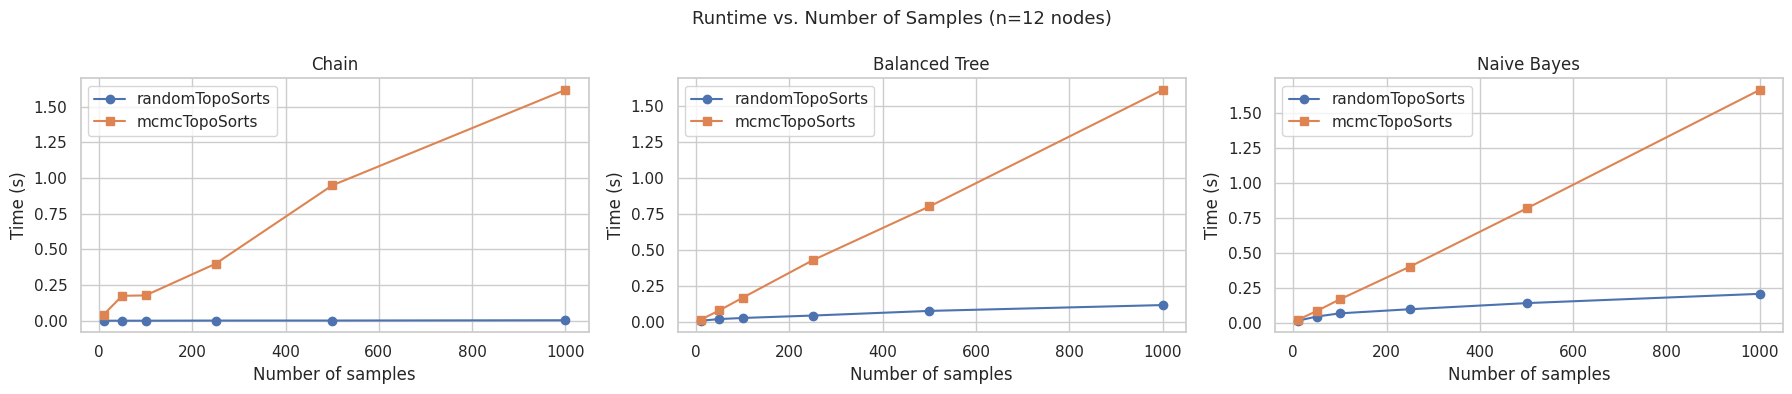

In [11]:
fig, axes = plt.subplots(1, len(graph_factories), figsize=(6 * len(graph_factories), 4), sharey=False)

for ax, (graph_name, _) in zip(axes, graph_factories.items()):
    sub = df_samples[df_samples['Graph'] == graph_name]
    ax.plot(sub['Samples'], sub['randomTopoSorts (s)'], marker='o', label='randomTopoSorts')
    ax.plot(sub['Samples'], sub['mcmcTopoSorts (s)'], marker='s', label='mcmcTopoSorts')
    ax.set_title(graph_name)
    ax.set_xlabel('Number of samples')
    ax.set_ylabel('Time (s)')
    ax.legend()

fig.suptitle(f'Runtime vs. Number of Samples (n={FIXED_N} nodes)', fontsize=13)
plt.tight_layout()
plt.show()

## Summary Table

In [12]:
print("=== Runtime by node count ===")
display(df_nodes.pivot_table(index=['Graph', 'Nodes'],
                              values=['randomTopoSorts (s)', 'mcmcTopoSorts (s)'],
                              aggfunc='first').round(4))

=== Runtime by node count ===


mcmcTopoSorts (s)  randomTopoSorts (s)
Graph         Nodes                                        
Balanced Tree 10                0.2100               0.0217
              12                0.3569               0.0514
              14                0.5037               0.0853
              16                0.7457               0.1729
              18                1.2156               0.3715
Chain         10                0.2218               0.0034
              12                0.3818               0.0017
              14                0.5090               0.0023
              16                0.7403               0.0031
              18                1.0720               0.0031
Naive Bayes   10                0.2128               0.0326
              12                0.4508               0.0955
              14                0.5665               0.3219
              16                0.8058               0.5694
              18                1.1670               0.9110

In [13]:
print("=== Runtime by sample count ===")
display(df_samples.pivot_table(index=['Graph', 'Samples'],
                                values=['randomTopoSorts (s)', 'mcmcTopoSorts (s)'],
                                aggfunc='first').round(4))

=== Runtime by sample count ===


mcmcTopoSorts (s)  randomTopoSorts (s)
Graph         Samples                                        
Balanced Tree 10                  0.0185               0.0112
              50                  0.0827               0.0226
              100                 0.1706               0.0301
              250                 0.4293               0.0469
              500                 0.8015               0.0790
              1000                1.6083               0.1193
Chain         10                  0.0439               0.0013
              50                  0.1756               0.0014
              100                 0.1782               0.0014
              250                 0.3998               0.0023
              500                 0.9482               0.0025
              1000                1.6164               0.0045
Naive Bayes   10                  0.0204               0.0139
              50                  0.0828               0.0435
              100                 0.1668               0.0666
              250                 0.4002               0.0959
              500                 0.8162               0.1397
              1000                1.6637               0.2059